In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')
rdir = '/home/kat/Repos/SALSA/results/'

In [2]:
import pandas as pd

runs = ['salsa','contra','ae','morgan']

df = pd.DataFrame()

for run in runs:
    _df = pd.read_csv(f'/home/kat/Repos/SALSA/mutual_infos/2022041804_04_12000n_extended_{run}.csv')
    _df['Run'] = run
    df = pd.concat((df,_df))

In [64]:
props = ['MolWt','HeavyAtomCount','FractionCSP3', 'TPSA', 'NumHAcceptors', 
         'NumHDonors', 'NumRotatableBonds', 'MolLogP']

usecols = ['Run','MolWt','HeavyAtomCount','FractionCSP3', 'TPSA', 'NumRotatableBonds', 'MolLogP']
usecols = ['Run','MolWt','FractionCSP3', 'TPSA', 'NumRotatableBonds', 'MolLogP']

df = df[usecols]
df

,Run,MolWt,FractionCSP3,TPSA,NumRotatableBonds,MolLogP
0,salsa,0.253637,6.004789e-07,0.070062,0.256685,0.030353
1,salsa,0.080362,1.377313e-01,0.000141,0.001925,0.038757
2,salsa,0.056961,1.195723e-02,0.044789,0.136221,0.000271
3,salsa,0.143544,2.516585e-02,0.006978,0.050043,0.004663
4,salsa,0.028324,2.259655e-01,0.005481,0.048175,0.027542
...,...,...,...,...,...,...
1019,morgan,0.000357,1.382734e-01,0.000724,0.005595,0.006182
1020,morgan,0.000192,4.252139e-05,0.000019,0.000019,0.000194
1021,morgan,0.000546,6.394093e-04,0.000025,0.000180,0.000001
1022,morgan,0.000160,3.493369e-04,0.000011,0.000114,0.000005


In [65]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def custom_vline(y, **kwargs):
    ym = y.mean()
    c = 'blue'
    plt.axvline(ym, color=c, linestyle="dashed",linewidth=3)
    plt.annotate(f"mean: {y.mean():.3f}", xy=(1,1), fontstyle="italic",
                 xycoords=plt.gca().get_yaxis_transform(), ha="right",color=c)
    
pal = ['purple', '#EE9A00', '#FFC125','yellowgreen']


# for prop in props:
#     df_plot = df[[prop,'Run']].reset_index(inplace=False)    
#     plt.figure(figsize=(10,5))
#     plt.title(prop)
    
#     sns.kdeplot(
#        data=df_plot, x=prop, hue="Run",
#        fill=True, common_norm=False, palette=pal,
#        alpha=.2, linewidth=1.,bw_adjust=.5)
    
#     plt.show()

In [66]:
# for prop in props:
#     df_plot = df[[prop,'Run']].reset_index(inplace=False, drop=True)    
#     plt.figure(figsize=(10,5))
#     plt.title(prop)
        
#     fig = sns.kdeplot(df_plot[df_plot.Run=='salsa'][prop], shade=True, color="purple")
#     fig = sns.kdeplot(df_plot[df_plot.Run=='contra'][prop], shade=True, color="orange")
#     fig = sns.kdeplot(df_plot[df_plot.Run=='ae'][prop], shade=True, color="green")
#     fig = sns.kdeplot(df_plot[df_plot.Run=='morgan'][prop], shade=True, color="blue")

#     plt.show()

In [67]:
# pal = ['purple', '#EE9A00', '#FFC125','yellowgreen']
# props = ['MolWt','HeavyAtomCount','FractionCSP3', 'TPSA', 'NumHAcceptors', 
#          'NumHDonors', 'NumRotatableBonds', 'MolLogP']

# for prop in props:
#     df_plot = df[[prop,'Run']].reset_index(inplace=False)    
#     plt.figure(figsize=(10,5))
#     plt.title(prop)
    
#     sns.boxplot(data=df_plot, y=prop, x="Run", palette=pal)
    
#     plt.show()

In [68]:
import numpy as np
from matplotlib.patches import PathPatch

def adjust_box_widths(g, fac):
    """
    Adjust the widths of a seaborn-generated boxplot.
    """

    # iterating through Axes instances
    for ax in g.axes:

        # iterating through axes artists:
        for c in ax.get_children():

            # searching for PathPatches
            if isinstance(c, PathPatch):
                # getting current width of box:
                p = c.get_path()
                verts = p.vertices
                verts_sub = verts[:-1]
                xmin = np.min(verts_sub[:, 0])
                xmax = np.max(verts_sub[:, 0])
                xmid = 0.5*(xmin+xmax)
                xhalf = 0.5*(xmax - xmin)

                # setting new width of box
                xmin_new = xmid-fac*xhalf
                xmax_new = xmid+fac*xhalf
                verts_sub[verts_sub[:, 0] == xmin, 0] = xmin_new
                verts_sub[verts_sub[:, 0] == xmax, 0] = xmax_new

                # setting new width of median line
                for l in ax.lines:
                    if np.all(l.get_xdata() == [xmin, xmax]):
                        l.set_xdata([xmin_new, xmax_new])

In [69]:
df_melt = pd.melt(df, var_name='Property',value_name='Mutual_info', id_vars=['Run'])

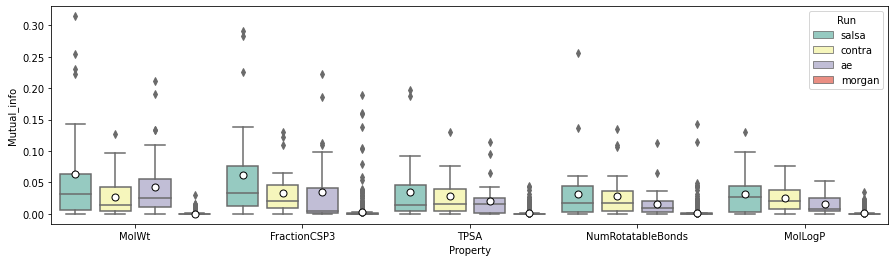

In [70]:
fig = plt.figure(figsize=(15,4))
ax = sns.boxplot(data=df_melt, x="Property", y="Mutual_info", hue="Run", 
                 palette="Set3", width=.95, showmeans=True,
                 meanprops={"marker":"o",
                            "markerfacecolor":"white", 
                            "markeredgecolor":"black",
                            "markersize":"7"})
adjust_box_widths(fig, 0.8)

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

def add_median_labels(ax, precision='.3f'):
    lines = ax.get_lines()
    boxes = [c for c in ax.get_children() if type(c).__name__ == 'PathPatch']
    lines_per_box = int(len(lines) / len(boxes))
    for median in lines[4:len(lines):lines_per_box]:
        x, y = (data.mean() for data in median.get_data())
        # choose value depending on horizontal or vertical plot orientation
        value = x if (median.get_xdata()[1] - median.get_xdata()[0]) == 0 else y
        text = ax.text(x, y+0.01, f'{value:{precision}}', ha='center', va='center',
                       fontweight='bold', color='blue')
        # create median-colored border around white text for contrast
        text.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'), # median.get_color()),
            path_effects.Normal(),
        ])

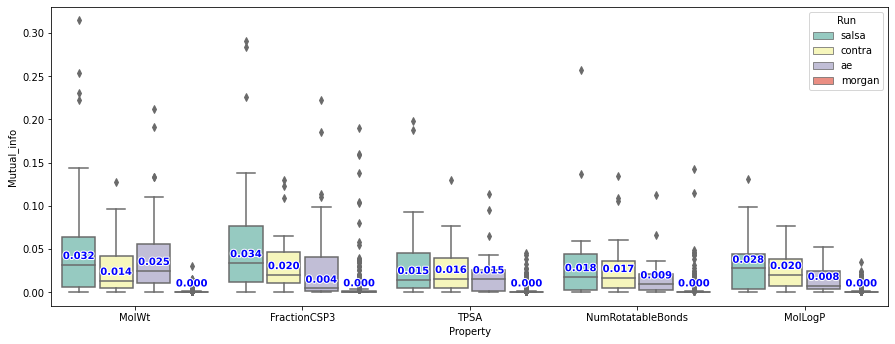

In [77]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5.5))
i_data, data_kwargs = {'x': 'Property', 'y': 'Mutual_info'}
ax = sns.boxplot(data=df_melt, x="Property", y="Mutual_info", hue="Run", 
                 palette="Set3", width=.9, showfliers=True)

add_median_labels(ax)
adjust_box_widths(fig, 0.9)
plt.show()